# Análisis de Clustering V3: Incorporación de Historial Obstétrico Adverso

En esta versión V3, se han añadido las variables `preterm_count` (partos prematuros previos) y `emergency_cesarean_count` (cesáreas de emergencia), manteniendo una regla física estricta para nulíparas.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar la vista de clustering v3
import os
for p in ['../data/v3/clustering_feature_view.csv', 'clustering/data/v3/clustering_feature_view.csv', 'data/v3/clustering_feature_view.csv']:
    if os.path.exists(p):
        df_full = pd.read_csv(p)
        break
else:
    raise FileNotFoundError('No se encontro el archivo clustering_feature_view.csv en ninguna de las rutas relativas posibles.')
df_features = df_full.drop(columns=['patient_id'])

# 2. Pipeline de preprocesamiento
num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_features.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(sparse_output=False, drop='first'))]), cat_cols)
])

X_processed = preprocessor.fit_transform(df_features)
print(f"Dimensiones post-preprocesamiento: {X_processed.shape}")

## Análisis de Componentes Principales (PCA)

In [ ]:
pca = PCA(random_state=42)
pca.fit(X_processed)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Componentes para retener el 80% de varianza: {n_components_80}")

pca_optimo = PCA(n_components=n_components_80, random_state=42)
X_cluster = pca_optimo.fit_transform(X_processed)
df_cluster = pd.DataFrame(X_cluster, columns=[f"PC{i+1}" for i in range(n_components_80)])

Componentes para retener el 80% de varianza: 14


## Determinación del Número de Clústeres (K)

K=2 -> Silhouette Score: 0.2248
K=3 -> Silhouette Score: 0.1179
K=4 -> Silhouette Score: 0.1423
K=5 -> Silhouette Score: 0.1481
K=6 -> Silhouette Score: 0.1637
K=7 -> Silhouette Score: 0.1555
K=8 -> Silhouette Score: 0.1598


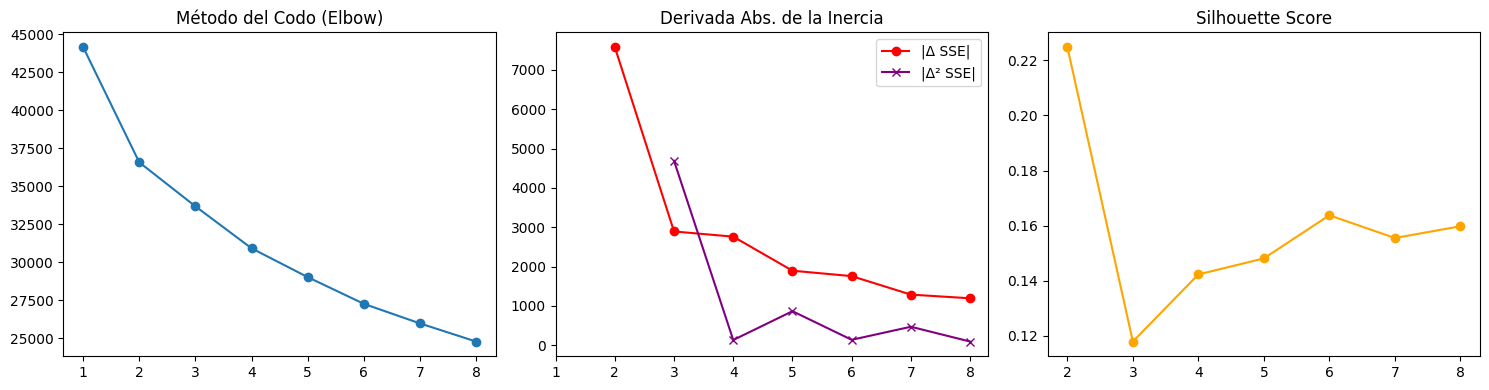

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sse = []
sil_scores = []
K_range = range(1, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sse.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_cluster, labels))
        print(f"K={k} -> Silhouette Score: {sil_scores[-1]:.4f}")

# Derivadas absolutas de la inercia
delta_sse = [abs(sse[i] - sse[i-1]) for i in range(1, len(sse))]
delta2_sse = [abs(delta_sse[i] - delta_sse[i-1]) for i in range(1, len(delta_sse))]

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(K_range, sse, marker='o')
plt.title('Método del Codo (Elbow)')
plt.xticks(K_range)

plt.subplot(1,3,2)
plt.plot(K_range[1:], delta_sse, marker='o', color='red', label='|Δ SSE|')
plt.plot(K_range[2:], delta2_sse, marker='x', color='purple', label='|Δ² SSE|')
plt.title('Derivada Abs. de la Inercia')
plt.xticks(K_range)
plt.legend()

plt.subplot(1,3,3)
plt.plot(K_range[1:], sil_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xticks(K_range[1:])
plt.tight_layout()
plt.show()


## Modelo Final (K=4) y Perfilado Clínico

In [ ]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_full['Cluster'] = km_final.fit_predict(X_cluster)

cols_clinicas = [
    'age_years', 'bmi_initial', 'mean_arterial_pressure', 'nulliparous',
    'previous_pregnancies', 'preterm_count', 'emergency_cesarean_count', 
    'previous_preeclampsia', 'diabetes', 'chronic_hypertension'
]
perfilado = df_full.groupby('Cluster')[cols_clinicas].mean().round(3)
print("PERFIL CLÍNICO V3:")
display(perfilado)

PERFIL CLÍNICO V3:


,age_years,bmi_initial,mean_arterial_pressure,nulliparous,previous_pregnancies,preterm_count,emergency_cesarean_count,previous_preeclampsia,diabetes,chronic_hypertension
Cluster,,,,,,,,,,
0,27.132,22.114,81.814,0.000,3.402,0.049,0.025,0.012,0.021,0.000
1,33.312,26.042,112.988,0.330,2.003,0.161,0.148,0.152,0.106,0.597
2,31.773,31.543,97.354,0.308,1.978,0.150,0.105,0.041,0.349,0.021
3,26.719,21.649,81.772,0.829,0.176,0.000,0.000,0.000,0.008,0.004


## DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

dbscan = DBSCAN(eps=3.0, min_samples=10)
db_labels = dbscan.fit_predict(X_cluster)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN descubrió {n_clusters} clústeres. Ruido: {n_noise} pacientes.")

DBSCAN descubrió 4 clústeres. Ruido: 378 pacientes.
